# Лабораторная работа №5: Градиентный бустинг

Автор: Федорова Софья Александровна, 6401-010302D

Датасет Pre-owner cars предоставляет исчерпывающую информацию о подержанных автомобилях, доступных в Индии. Он предлагает ценные инсайты для исследователей, аналитиков и компаний, работающих в автомобильной отрасли, особенно для тех, кто интересуется тенденциями рынка подержанных автомобилей, ценами и предпочтениями клиентов. Целевой признак - цена автомобиля.

Ссылка на датасет: https://www.kaggle.com/datasets/mrmars1010/cars-india-pre-owned

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
import scipy.stats
import  plotly
from matplotlib.ticker import ScalarFormatter

## 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

### Считывание датасета из csv-файла

In [2]:
file = 'pre-owned_cars.csv'

df = pd.read_csv(file)

## 2.  Датасет и подготовка данных:

#### Привести описание датасета.


  
   | Признак | Тип признака | Описание | Единицы измерения |   
   | --- | --- | --- | --- |
   | brand | categorical | Марка или производитель автомобиля |  
   | model | categorical | Конкретная модель автомобиля|
   | transmission | categorical | Тип трансмиссии | **целевой признак в задачах бинарной классификации**
   | make_year | categorical |Год производства автомобиля |
   | reg_year | categorical | Год регистрации автомобиля |
   | fuel_type  | categorical | Тип топлива, используемого автомобилем | **целевой признак в задачах многоклассовой классификации**
   | engine_capacity(CC) | quantitative | Объём двигателя в кубических сантиметрах | sm**3
   | km_driven | quantitative | Общее расстояние, которое автомобиль прошёл | km
   | ownership | categorical | Количество предыдущих владельцев автомобиля |
   | **price** | **quantitative** | **Запрашиваемая цена за машину** | какая-то валюта (целевой признак в задаче регрессии)
   | overall_cost | quantitative  | Издержки |
   | has_insurance | categorical | Наличие страховки на машину |
   | spare_key | categorical | Наличие запасного ключа |
   | reg_number | categorical | Регистрационный номер |
   | title  | categorical | Краткая информация о машине (марка, год выпуска, бренд) |



#### Осуществить предобработку данных (избавиться от null, убрать некоторые признаки и т.п.) – "подчистить данные".

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

Год регистрации автомобиля `reg_year` коррелирует с годом выпуска, поэтому можно избавиться от этого столбца.

Также столбец `title` дублирует информацию, хранящуюся в таблице (title = make_year + brand + model), поэтому его тоже удалим.

In [4]:
df.drop(columns=['reg_year', 'title'], inplace=True)

In [5]:
df = df.dropna()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2688 entries, 0 to 2804
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2688 non-null   object 
 1   model                2688 non-null   object 
 2   transmission         2688 non-null   object 
 3   make_year            2688 non-null   float64
 4   fuel_type            2688 non-null   object 
 5   engine_capacity(CC)  2688 non-null   float64
 6   km_driven            2688 non-null   float64
 7   ownership            2688 non-null   object 
 8   price                2688 non-null   int64  
 9   overall_cost         2688 non-null   float64
 10  has_insurance        2688 non-null   object 
 11  spare_key            2688 non-null   object 
 12  reg_number           2688 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 294.0+ KB


#### Нормализовать данные.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.describe().columns.tolist()

scaler.fit(df[numeric_cols])

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


#### Закодировать категориальные признаки при необходимости.
> Кодировать признаки или нет для `XGBoost`/`CatBoost` &ndash; на ваше усмотрение.  
> В явном виде текстом описать применяется ли кодирование категориальных признаков и с какими параметрами.

In [8]:
numeric_cols =  ['price', 'km_driven', 'engine_capacity(CC)', 'make_year', 'overall_cost']
categorial_cols = ['brand', 'model', 'transmission', 'fuel_type', 'ownership', 'has_insurance', 'spare_key', 'reg_number']

df_categorial = df[categorial_cols]
df_categorial['model'].value_counts().sort_index() #категория model содержит 785 уникальных значений
df_categorial['brand'].value_counts().sort_index() #категория brand содержит 15 уникальных значений
df_categorial['transmission'].value_counts().sort_index() #категория transmission содержит 2 уникальных значения
df_categorial['fuel_type'].value_counts().sort_index() #категория fuel_type содержит 3 уникальных значения

df_categorial['ownership'].value_counts().sort_index() #категория ownership содержит 3 уникальных значения
df_categorial['has_insurance'].value_counts().sort_index() #категория has_insurance содержит только True
df_categorial['spare_key'].value_counts().sort_index() #категория spare_key содержит 2 уникальных значения (No-1962, Yes-726)
df_categorial['reg_number'].value_counts().sort_index(); #категория reg_number содержит 153 уникальных значения

В результате анализа уникальных значений для категориальных признаков, удаляем признак `has_insurance`, содержащий только значения одного класса. Целевым классом в задаче классификации будет `transmission`.

In [9]:
df = df.drop(columns='has_insurance');

Для кодирования признаков будем применять `One-Hot Encoding`, хотя размерность данных увеличится в несколько раз и будет содержать 961 признак. Чтобы избежать этого удалим классы, которые содержат большое количество уникальных значений - `model`и `reg_number`, оставив при этом остальные значимые признаки.

In [10]:
df = df.drop(columns=['model', 'reg_number']);

In [11]:
df_encoded = df.copy()

onehot_cols = ['transmission', 'ownership', 'spare_key','brand', 'fuel_type']
df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, drop_first=True)

Не будем применять кодирование категориальных признаков для `XGBoost`/`CatBoost`, воспользуемся встроенными способами.

#### Разбить выборку на обучающую и тестовую.

Разбиваем выборку для некодированных признаков.

In [12]:
from sklearn.model_selection import train_test_split

target = df['transmission']
X = df.drop(columns=['transmission'])
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.75, random_state=42
)

Разбиваем выборку для декодированных признаков.

In [13]:
from sklearn.model_selection import train_test_split

target_encoded = df_encoded['transmission_Manual']
X_encoded = df_encoded.drop(columns=['transmission_Manual'])
y_encoded = target_encoded

X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(
    X_encoded, y_encoded, stratify=y, train_size=0.75, random_state=42
)

#### При наличии дисбаланса классов снизить дисбаланс классов в обучающей выборке.

In [14]:
print(y_train_encoded.value_counts(normalize=True))

transmission_Manual
True     0.687004
False    0.312996
Name: proportion, dtype: float64


В нашей целевой переменной есть дисбаланс, который будем снижать с помощью метода `SMOTE`. Метод находит ближайших соседей миноритарного класса и генерирует образцы, делая линейную интерполяцию между ними. Обычно образец выбирается случайным образом из малочисленного класса. Это делается для того, чтобы обеспечить разнообразие и предотвратить смещение в сторону какой-либо конкретной области пространства признаков.

Применим метод для декодированных данных.

In [15]:
from imblearn.combine import SMOTETomek

# SMOTE + Tomek links (удаляет "шумные" образцы)
smote_tomek = SMOTETomek(random_state=42)
X_train_encoded_resampled, y_train_encoded_resampled = smote_tomek.fit_resample(X_train_encoded, y_train_encoded)

print(pd.Series(y_train_encoded_resampled).value_counts().sort_index())

transmission_Manual
False    1303
True     1303
Name: count, dtype: int64


Применим метод для не декодированных данных.

In [16]:
categorial_cols_train = ['brand',
 'fuel_type',
 'ownership',
 'spare_key']

In [17]:
# SMOTE-NC (SMOTE for Nominal Continuous) - для смешанных данных
from imblearn.over_sampling import SMOTENC

# индексы категориальных признаков
categorical_indices = [X_train.columns.get_loc(col) for col in categorial_cols_train]

smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

print(pd.Series(y_train_resampled).value_counts().sort_index())

transmission
Automatic    1385
Manual       1385
Name: count, dtype: int64


**Примечание о кодировании категориальных признаков:**

Для `AdaBoost` и `GradientBoosting` – применяется one-hot кодирование через pd.get_dummies.
Для XGBoost – используется `enable_categorical=True` (XGBoost 1.6+), категориальные признаки передаются как есть с указанием `feature_types`.
Для CatBoost – категориальные признаки передаются напрямую с указанием `cat_features`.

Все тренировочные данные мы избавили от дисбаланса внутри класса с применением `SMOTE-NC`.

## 3. Для каждого из классификаторов ($AdaBoost$, $GradientBoostingClassifier$, $XGBoost$, $CatBoost$):

- С использованием `GridSearchCV`/`grid_search` осуществить подбор гиперпараметра модели.
> Как минимум основных: `n_estimators`/`iterations`, `learning_rate`, `depth`, параметры регуляризации $L^1$, $L^2$.
- Построить `ROC` и `Precision-Recall` графики для обучающей и тестовой выборок.
- Вывести метрики на тестовом наборе (как минимум `classification_report`, другие по желанию).

**$AdaBoost$**

У классификатора [sklearn.ensemble.AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) два основных гиперпараметра:
- `n_estimators` &ndash; максимальное количество классификаторов для бустинга, диапазон значений: $[1, \infty)$. Значение по умолчанию $50$.
- `learning_rate` &ndash; значение веса, применяемого к классификатору на каждой итерации бустинга, диапазон значений: $(0.0, \infty)$. Значение по умолчанию $1.0$.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

ada_params = {'n_estimators': [50, 100, 200],
             'learning_rate': [0.01, 0.1, 1.0, 10.0]}

grid_ada = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1)


grid_ada.fit(X_train_encoded_resampled, y_train_encoded_resampled)

best_ada = grid_ada.best_estimator_
y_pred_ada = best_ada.predict(X_test_encoded)
y_proba_ada = best_ada.predict_proba(X_test_encoded)[:, 1] #оцениваем вероятность отнесения к классу
y_proba_train = best_ada.predict_proba(X_train_encoded_resampled)[:, 1]

print("AdaBoost лучшие параметры:", grid_ada.best_params_)
print("Classification report:")
print(classification_report(y_test_encoded, y_pred_ada))

AdaBoost лучшие параметры: {'learning_rate': 1.0, 'n_estimators': 200}
Classification report:
              precision    recall  f1-score   support

       False       0.49      0.70      0.57       210
        True       0.83      0.67      0.74       462

    accuracy                           0.68       672
   macro avg       0.66      0.68      0.66       672
weighted avg       0.72      0.68      0.69       672



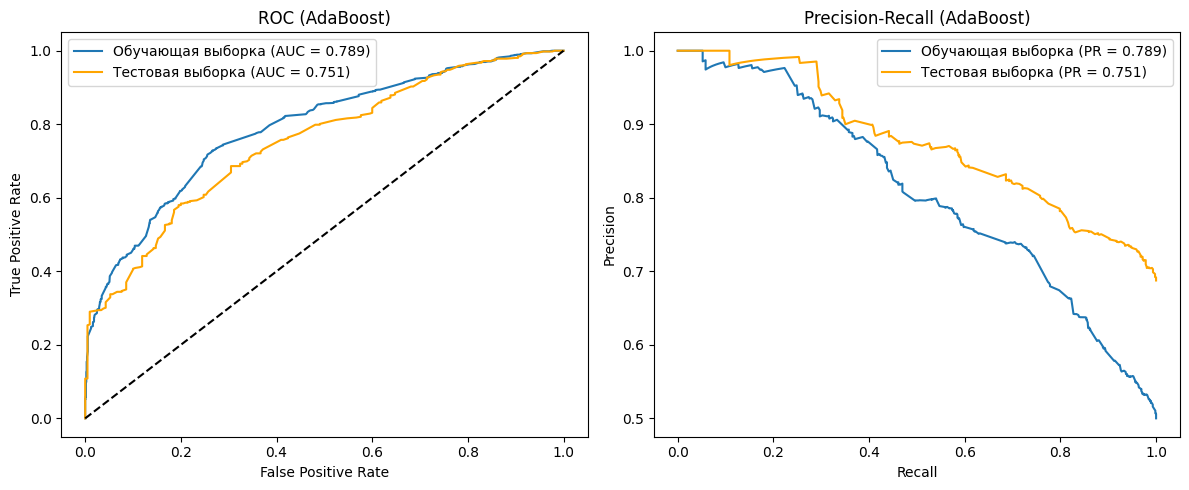

In [ ]:
from sklearn.metrics import auc, precision_recall_curve, roc_curve

fpr_ada_train, tpr_ada_train, _ = roc_curve(y_train_encoded_resampled, y_proba_train)
roc_auc_ada_train = auc(fpr_ada_train, tpr_ada_train)

precision_ada_train, recall_ada_train, _ = precision_recall_curve(y_train_encoded_resampled, y_proba_train)

fpr_ada_test, tpr_ada_test, _ = roc_curve(y_test_encoded, y_proba_ada)
roc_auc_ada_test = auc(fpr_ada_test, tpr_ada_test)

precision_ada_test, recall_ada_test, _ = precision_recall_curve(y_test_encoded, y_proba_ada)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_ada_train, tpr_ada_train, label=f'Обучающая выборка (AUC = {roc_auc_ada_train:.3f})')
axes[0].plot(fpr_ada_test, tpr_ada_test, label=f'Тестовая выборка (AUC = {roc_auc_ada_test:.3f})', color='orange')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC (AdaBoost)')
axes[0].legend()

axes[1].plot(recall_ada_train, precision_ada_train, label=f'Обучающая выборка (PR = {roc_auc_ada_train:.3f})')
axes[1].plot(recall_ada_test, precision_ada_test, label=f'Тестовая выборка (PR = {roc_auc_ada_test:.3f})', color='orange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (AdaBoost)')
axes[1].legend()

plt.tight_layout()
plt.show()

**$GradientBoost$**

У классификатора [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) три *основных* гиперпараметра:
- `n_estimators` &ndash; максимальное количество итераций бустинга, диапазон значений: $[1, \infty)$. Значение по умолчанию $100$.
- `learning_rate` &ndash; значение веса, применяемого к классификатору на каждой итерации бустинга, диапазон значений: $[0.0, \infty)$. Значение по умолчанию $0.1$.
- `max_depth` &ndash; максимальное количество вершин в дереве, диапазон значений: $[1, \infty)$. Значение по умолчанию $3$.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbm_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0, 10.0],
    'max_depth': range(1, 10),
}

gbm_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gbm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gbm_grid.fit(X_train_encoded_resampled, y_train_encoded_resampled)

best_gbm = gbm_grid.best_estimator_
y_pred_gbm = best_gbm.predict(X_test_encoded)
y_proba_gbm = best_gbm.predict_proba(X_test_encoded)[:, 1] #оцениваем вероятность отнесения к классу
y_proba_train_gbm = best_gbm.predict_proba(X_train_encoded_resampled)[:, 1]

print("GradientBoost лучшие параметры:", gbm_grid.best_params_)
print("Classification report:")
print(classification_report(y_test_encoded, y_pred_gbm))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
GradientBoost лучшие параметры: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Classification report:
              precision    recall  f1-score   support

       False       0.59      0.58      0.58       210
        True       0.81      0.82      0.81       462

    accuracy                           0.74       672
   macro avg       0.70      0.70      0.70       672
weighted avg       0.74      0.74      0.74       672



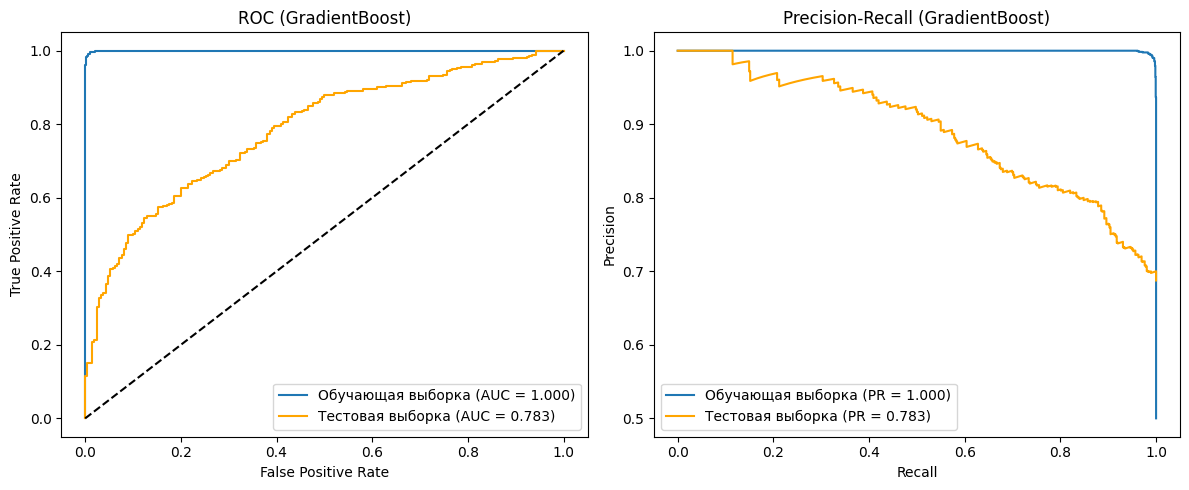

In [ ]:
from sklearn.metrics import auc, precision_recall_curve, roc_curve

fpr_gbm_train, tpr_gbm_train, _ = roc_curve(y_train_encoded_resampled, y_proba_train_gbm)
roc_auc_gbm_train = auc(fpr_gbm_train, tpr_gbm_train)

precision_gbm_train, recall_gbm_train, _ = precision_recall_curve(y_train_encoded_resampled, y_proba_train_gbm)

fpr_gbm_test, tpr_gbm_test, _ = roc_curve(y_test_encoded, y_proba_gbm)
roc_auc_gbm_test = auc(fpr_gbm_test, tpr_gbm_test)

precision_gbm_test, recall_gbm_test, _ = precision_recall_curve(y_test_encoded, y_proba_gbm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_gbm_train, tpr_gbm_train, label=f'Обучающая выборка (AUC = {roc_auc_gbm_train:.3f})')
axes[0].plot(fpr_gbm_test, tpr_gbm_test, label=f'Тестовая выборка (AUC = {roc_auc_gbm_test:.3f})', color='orange')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC (GradientBoost)')
axes[0].legend()

axes[1].plot(recall_gbm_train, precision_gbm_train, label=f'Обучающая выборка (PR = {roc_auc_gbm_train:.3f})')
axes[1].plot(recall_gbm_test, precision_gbm_test, label=f'Тестовая выборка (PR = {roc_auc_gbm_test:.3f})', color='orange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (GradientBoost)')
axes[1].legend()

plt.tight_layout()
plt.show()

**$XGBoost$**

Параметры для бустинга на деревьях ([Parameters for Tree Booster](https://xgboost.readthedocs.io/en/stable/parameter.html#parameters-for-tree-booster)):
- `eta` или `learning_rate` &ndash; скорость обучения. Диапазон значений: $[0, 1]$. Значение по умолчанию $0.3$.
- `lambda` или `reg_lambda` &ndash; параметр $L_2$ регуляризации. Диапазон значений: $[0, \infty]$. Значение по умолчанию $1$.
- `alpha` или `reg_alpha` &ndash; параметр $L_1$ регуляризации. Диапазон значений: $[0, \infty]$. Значение по умолчанию $0$.

In [ ]:
from sklearn.preprocessing import LabelEncoder


for i in categorial_cols_train:
    X_test[i] = X_test[i].astype('category')
    X_train_resampled[i] = X_train_resampled[i].astype('category')

le = LabelEncoder()
y_train_resampled = le.fit_transform(y_train_resampled)  # 'Automatic' -> 0, 'Manual' -> 1
y_test = le.transform(y_test)


In [ ]:
import xgboost as xgb

xgb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0, 10.0],
    'max_depth': range(1, 10),
    'reg_lambda': [ 0.1, 1.0, 5.0],
    'reg_alpha': [0.1, 1.0, 5.0]
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, enable_categorical=True),
    param_grid=xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_resampled, y_train_resampled)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb= best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1] #оцениваем вероятность отнесения к классу
y_proba_train_xgb = best_xgb.predict_proba(X_train_resampled)[:, 1]

print("XGBoost лучшие параметры:", xgb_grid.best_params_)
print("Classification report:")
print(classification_report(y_test, y_pred_xgb))


Fitting 5 folds for each of 972 candidates, totalling 4860 fits
XGBoost лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 1.0, 'reg_lambda': 0.1}
Classification report:
              precision    recall  f1-score   support

           0       0.59      0.58      0.58       210
           1       0.81      0.82      0.81       462

    accuracy                           0.74       672
   macro avg       0.70      0.70      0.70       672
weighted avg       0.74      0.74      0.74       672



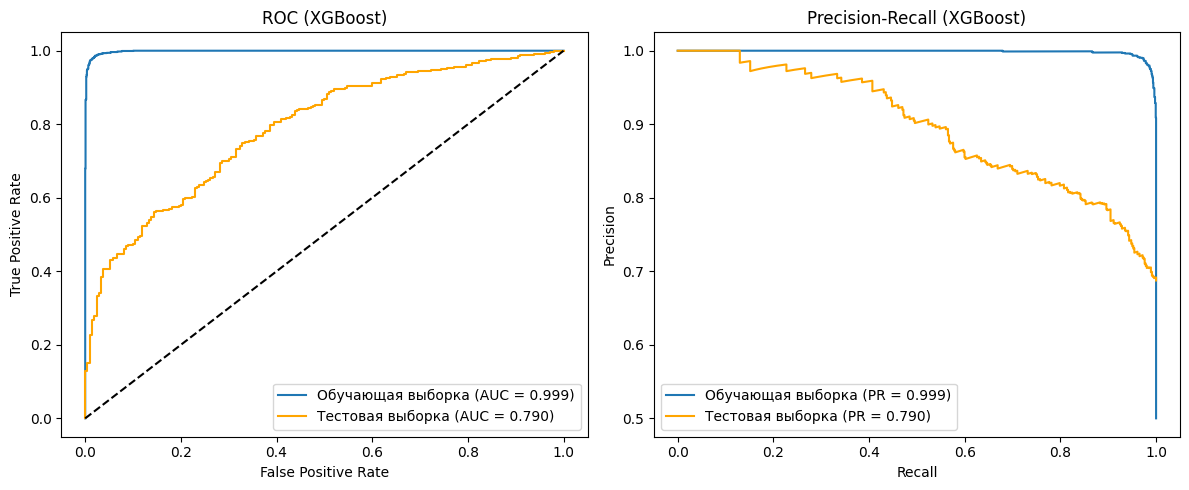

In [ ]:
from sklearn.metrics import auc, precision_recall_curve, roc_curve

fpr_xgb_train, tpr_xgb_train, _ = roc_curve(y_train_resampled, y_proba_train_xgb)
roc_auc_xgb_train = auc(fpr_xgb_train, tpr_xgb_train)

precision_xgb_train, recall_xgb_train, _ = precision_recall_curve(y_train_resampled, y_proba_train_xgb)

fpr_xgb_test, tpr_xgb_test, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb_test = auc(fpr_xgb_test, tpr_xgb_test)

precision_xgb_test, recall_xgb_test, _ = precision_recall_curve(y_test, y_proba_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_xgb_train, tpr_xgb_train, label=f'Обучающая выборка (AUC = {roc_auc_xgb_train:.3f})')
axes[0].plot(fpr_xgb_test, tpr_xgb_test, label=f'Тестовая выборка (AUC = {roc_auc_xgb_test:.3f})', color='orange')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC (XGBoost)')
axes[0].legend()

axes[1].plot(recall_xgb_train, precision_xgb_train, label=f'Обучающая выборка (PR = {roc_auc_xgb_train:.3f})')
axes[1].plot(recall_xgb_test, precision_xgb_test, label=f'Тестовая выборка (PR = {roc_auc_xgb_test:.3f})', color='orange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (XGBoost)')
axes[1].legend()

plt.tight_layout()
plt.show()

**$CatBoost$**

In [ ]:
import catboost as cb

cat_params = {
    'iterations': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'depth': range(3, 8),
    'l2_leaf_reg': [0.1, 1.0, 10.0]
}

cat_features_indices = [X_train.columns.get_loc(c) for c in categorial_cols_train]

cat_grid = GridSearchCV(
    cb.CatBoostClassifier(random_state=42),
    param_grid=cat_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

cat_grid.fit(X_train_resampled, y_train_resampled, cat_features=cat_features_indices)

best_cat = cat_grid.best_estimator_
y_pred_cat = best_cat.predict(X_test)
y_proba_cat = best_cat.predict_proba(X_test)[:, 1] #оцениваем вероятность отнесения к классу
y_proba_train_cat = best_cat.predict_proba(X_train_resampled)[:, 1]

print("CatBoost лучшие параметры:", cat_grid.best_params_)
print("Classification report:")
print(classification_report(y_test, y_pred_cat))


Fitting 5 folds for each of 135 candidates, totalling 675 fits
0:	learn: 0.6690703	total: 59.8ms	remaining: 11.9s
1:	learn: 0.6473783	total: 70.1ms	remaining: 6.94s
2:	learn: 0.6296252	total: 79.5ms	remaining: 5.22s
3:	learn: 0.6190919	total: 87.8ms	remaining: 4.3s
4:	learn: 0.6118960	total: 93.4ms	remaining: 3.64s
5:	learn: 0.6029574	total: 103ms	remaining: 3.33s
6:	learn: 0.6007196	total: 107ms	remaining: 2.95s
7:	learn: 0.5892561	total: 117ms	remaining: 2.81s
8:	learn: 0.5823544	total: 127ms	remaining: 2.69s
9:	learn: 0.5765416	total: 136ms	remaining: 2.58s
10:	learn: 0.5687596	total: 145ms	remaining: 2.49s
11:	learn: 0.5631090	total: 154ms	remaining: 2.41s
12:	learn: 0.5586553	total: 163ms	remaining: 2.34s
13:	learn: 0.5547509	total: 171ms	remaining: 2.27s
14:	learn: 0.5502197	total: 179ms	remaining: 2.21s
15:	learn: 0.5435799	total: 187ms	remaining: 2.15s
16:	learn: 0.5396400	total: 196ms	remaining: 2.11s
17:	learn: 0.5371659	total: 204ms	remaining: 2.06s
18:	learn: 0.5302606	tota

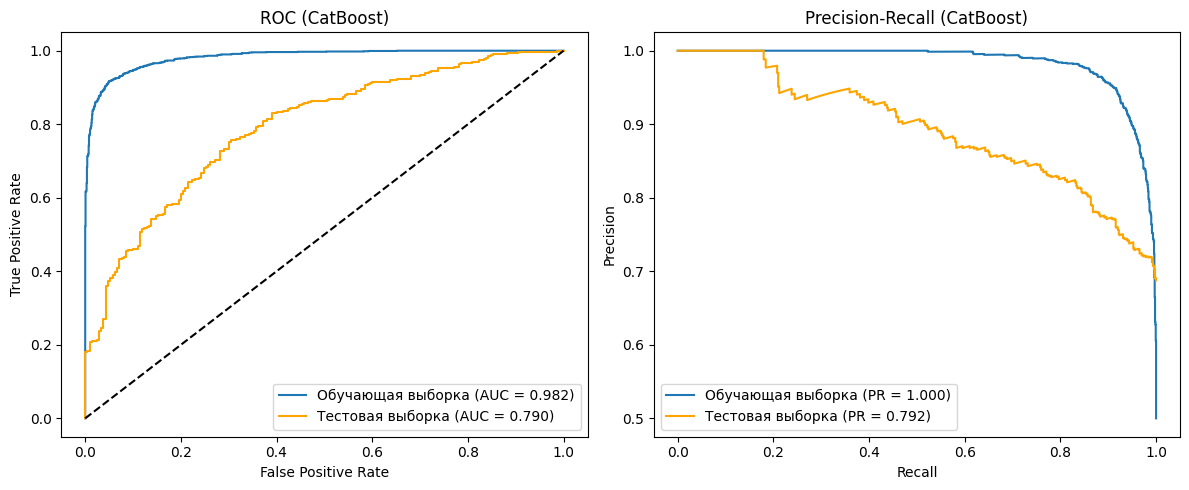

In [ ]:
from sklearn.metrics import auc, precision_recall_curve, roc_curve

fpr_cat_train, tpr_cat_train, _ = roc_curve(y_train_resampled, y_proba_train_cat)
roc_auc_cat_train = auc(fpr_cat_train, tpr_cat_train)

precision_cat_train, recall_cat_train, _ = precision_recall_curve(y_train_resampled, y_proba_train_cat)

fpr_cat_test, tpr_cat_test, _ = roc_curve(y_test, y_proba_cat)
roc_auc_cat_test = auc(fpr_cat_test, tpr_cat_test)

precision_cat_test, recall_cat_test, _ = precision_recall_curve(y_test, y_proba_cat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_cat_train, tpr_cat_train, label=f'Обучающая выборка (AUC = {roc_auc_cat_train:.3f})')
axes[0].plot(fpr_cat_test, tpr_cat_test, label=f'Тестовая выборка (AUC = {roc_auc_xgb_test:.3f})', color='orange')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC (CatBoost)')
axes[0].legend()

axes[1].plot(recall_cat_train, precision_cat_train, label=f'Обучающая выборка (PR = {roc_auc_gbm_train:.3f})')
axes[1].plot(recall_cat_test, precision_cat_test, label=f'Тестовая выборка (PR = {roc_auc_cat_test:.3f})', color='orange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (CatBoost)')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Сравнить модели, выбрать лучшую.

Датасет содержал несбалансированные классы целевой переменной, после балансировки модели были обучены на этих данных,поэтому оценивать качество моделей стоит на тестовых данных по метрике `ROC`. Лучшее значение достигается для модели  `CatBoost` с параметрами `{'depth': 7, 'iterations': 200, 'l2_leaf_reg': 0.1, 'learning_rate': 0.1}`.

## 4. Важность признаков

#### С использованием `shap.TreeExplainer` получить $SHAP$-значения для лучшей модели.

In [26]:
import shap
import catboost as cb

best_model = cb.CatBoostClassifier(
    depth = 7,
    iterations = 200,
    l2_leaf_reg = 0.1,
    learning_rate = 0.1,
    verbose=False
)

cat_features_indices = [X_train_resampled.columns.get_loc(c) for c in categorial_cols_train]

best_model.fit(X_train_resampled, y_train_resampled, cat_features=cat_features_indices)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)
shap_values_array = shap_values.values

shap.initjs()

#### Построить график `shap.plots.force` для одного объекта выборки и для среза произвольного размера.

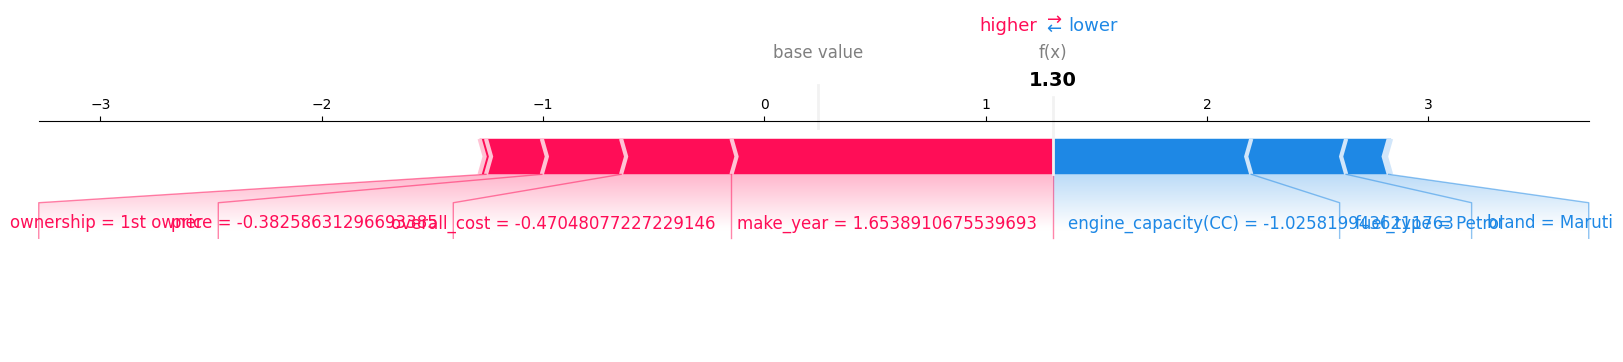

In [32]:
shap_fp = shap.plots.force(explainer.expected_value, shap_values_array[0, :], X_test.iloc[0, :], matplotlib=True)

#### Построить график `shap.plots.bar` для одного объекта выборки.

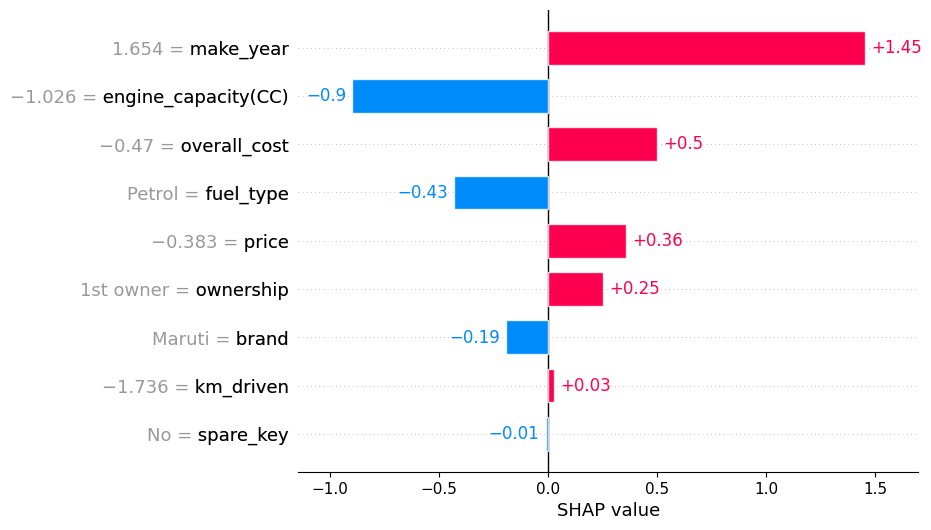

In [33]:
shap.plots.bar(shap_values[0])

#### Построить график `shap.plots.waterfall` для одного объекта выборки.

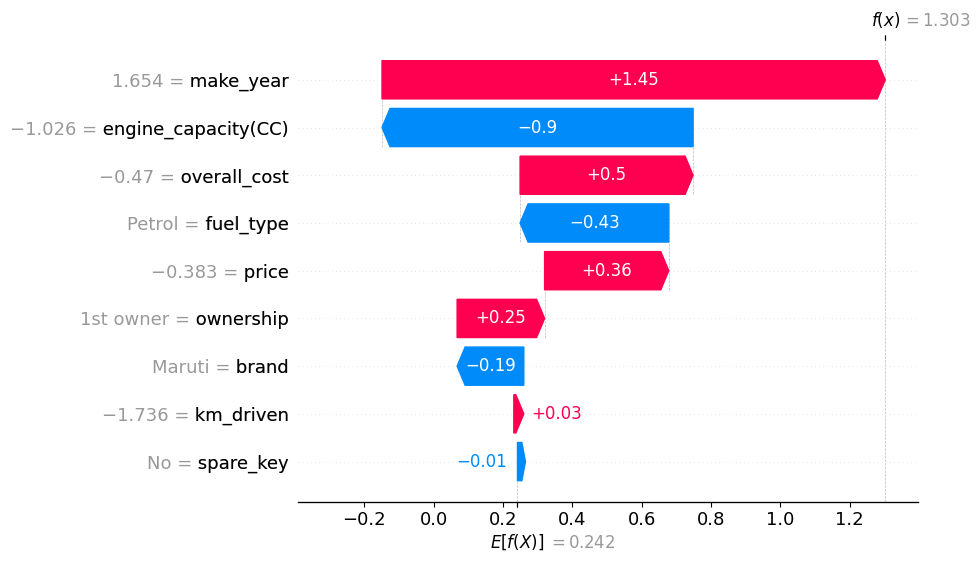

In [34]:
shap.plots.waterfall(shap_values[0], max_display=10)

#### Построить 2 графика `shap.plots.scatter` для какого-нибудь признака. На одном раскрасить относительно себя, на втором &ndash; относительно другого признака.

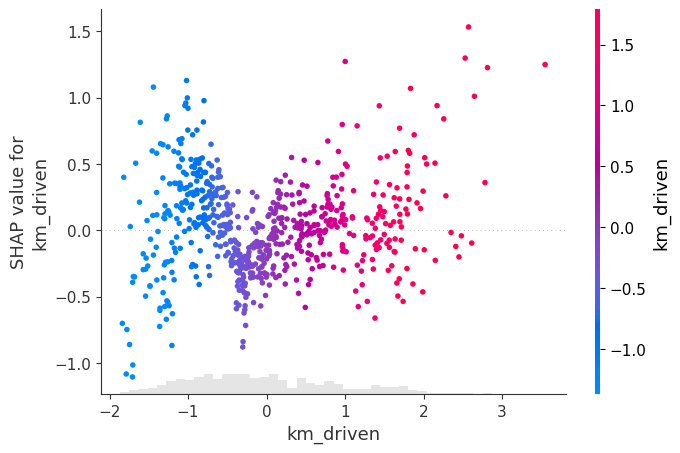

In [35]:
shap.plots.scatter(shap_values[:, 'km_driven'], color=shap_values[:, 'km_driven'])

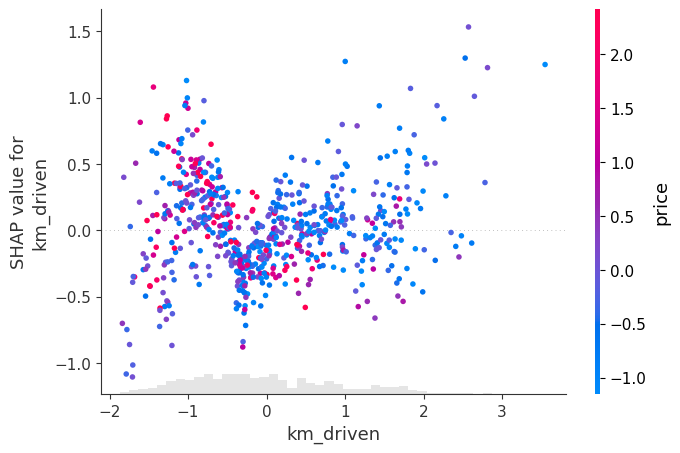

In [36]:
shap.plots.scatter(shap_values[:, 'km_driven'],   color=shap_values[:, 'price'])

#### Построить график `shap.plots.beeswarm` для всех признаков.

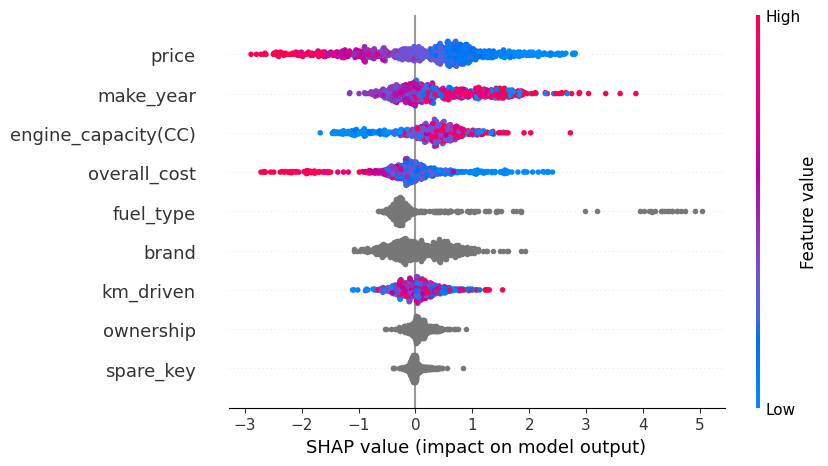

In [37]:
shap.plots.beeswarm(shap_values)

#### Построить график `shap.plots.bar` для всех признаков.

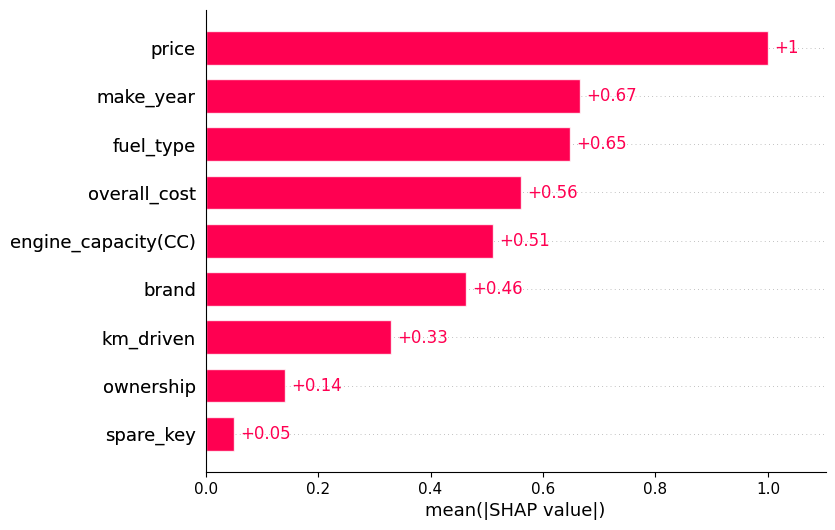

In [38]:
shap.plots.bar(shap_values[:20])

#### На основании двух последних графиков и/или используя `feature_importance` отфильтровать признаки (отразить сформулированные выводы в тексте), переобучить лучшую модель.

In [46]:
feature_importance = best_model.get_feature_importance()

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Важность признаков (CatBoost):")
print(importance_df)

Важность признаков (CatBoost):
               feature  importance
1            make_year   26.664263
0                brand   12.874630
3  engine_capacity(CC)   12.702633
4            km_driven   11.268037
7         overall_cost   10.892833
6                price   10.853379
2            fuel_type    7.474729
5            ownership    4.606368
8            spare_key    2.663128


In [49]:
important_feature = importance_df.feature[importance_df.importance > np.median(importance_df.importance)]

   - Переобучить модель на отфильтрованном наборе признаков.

In [53]:
categorial_cols_filtered = ['brand']

In [59]:
from sklearn.metrics import classification_report

X_train_resampled = X_train_resampled[important_feature]
X_test = X_test[important_feature]

cat_features_indices = [X_train_resampled.columns.get_loc(c) for c in categorial_cols_filtered]

best_model.fit(X_train_resampled, y_train_resampled, cat_features=cat_features_indices)

y_pred_filtered = best_model.predict(X_test)
y_proba_filtered = best_model.predict_proba(X_test)[:, 1] #оцениваем вероятность отнесения к классу
y_proba_train_filtered = best_model.predict_proba(X_train_resampled)[:, 1]

print("Classification report:")
print(classification_report(y_test, y_pred_filtered))


Classification report:
              precision    recall  f1-score   support

   Automatic       0.47      0.49      0.48       210
      Manual       0.76      0.76      0.76       462

    accuracy                           0.67       672
   macro avg       0.62      0.62      0.62       672
weighted avg       0.67      0.67      0.67       672



Ранее с теми же параметрами результаты были такими:

 Classification report:

| | Precision | Recall | F1-score | Support |
|-|----------:|-------:|---------:|--------:|
| **Class 0** | 0.62 | 0.60 | 0.61 | 210 |
| **Class 1** | **0.82** | **0.83** | **0.83** | 462 |
| | | | | |
| **Accuracy** | | | **0.76** | 672 |
| **Macro avg** | 0.72 | 0.72 | 0.72 | 672 |
| **Weighted avg** | 0.76 | 0.76 | 0.76 | 672 |


Таким образом, при сокращении признаков вдвое точность распознавания каждого класса снизилась, что сказалось на итоговой оценки для точности, ранее ее значение было равно 0,76, сейчас - 0,67.

#### Визуализировать полученное дерево решений.

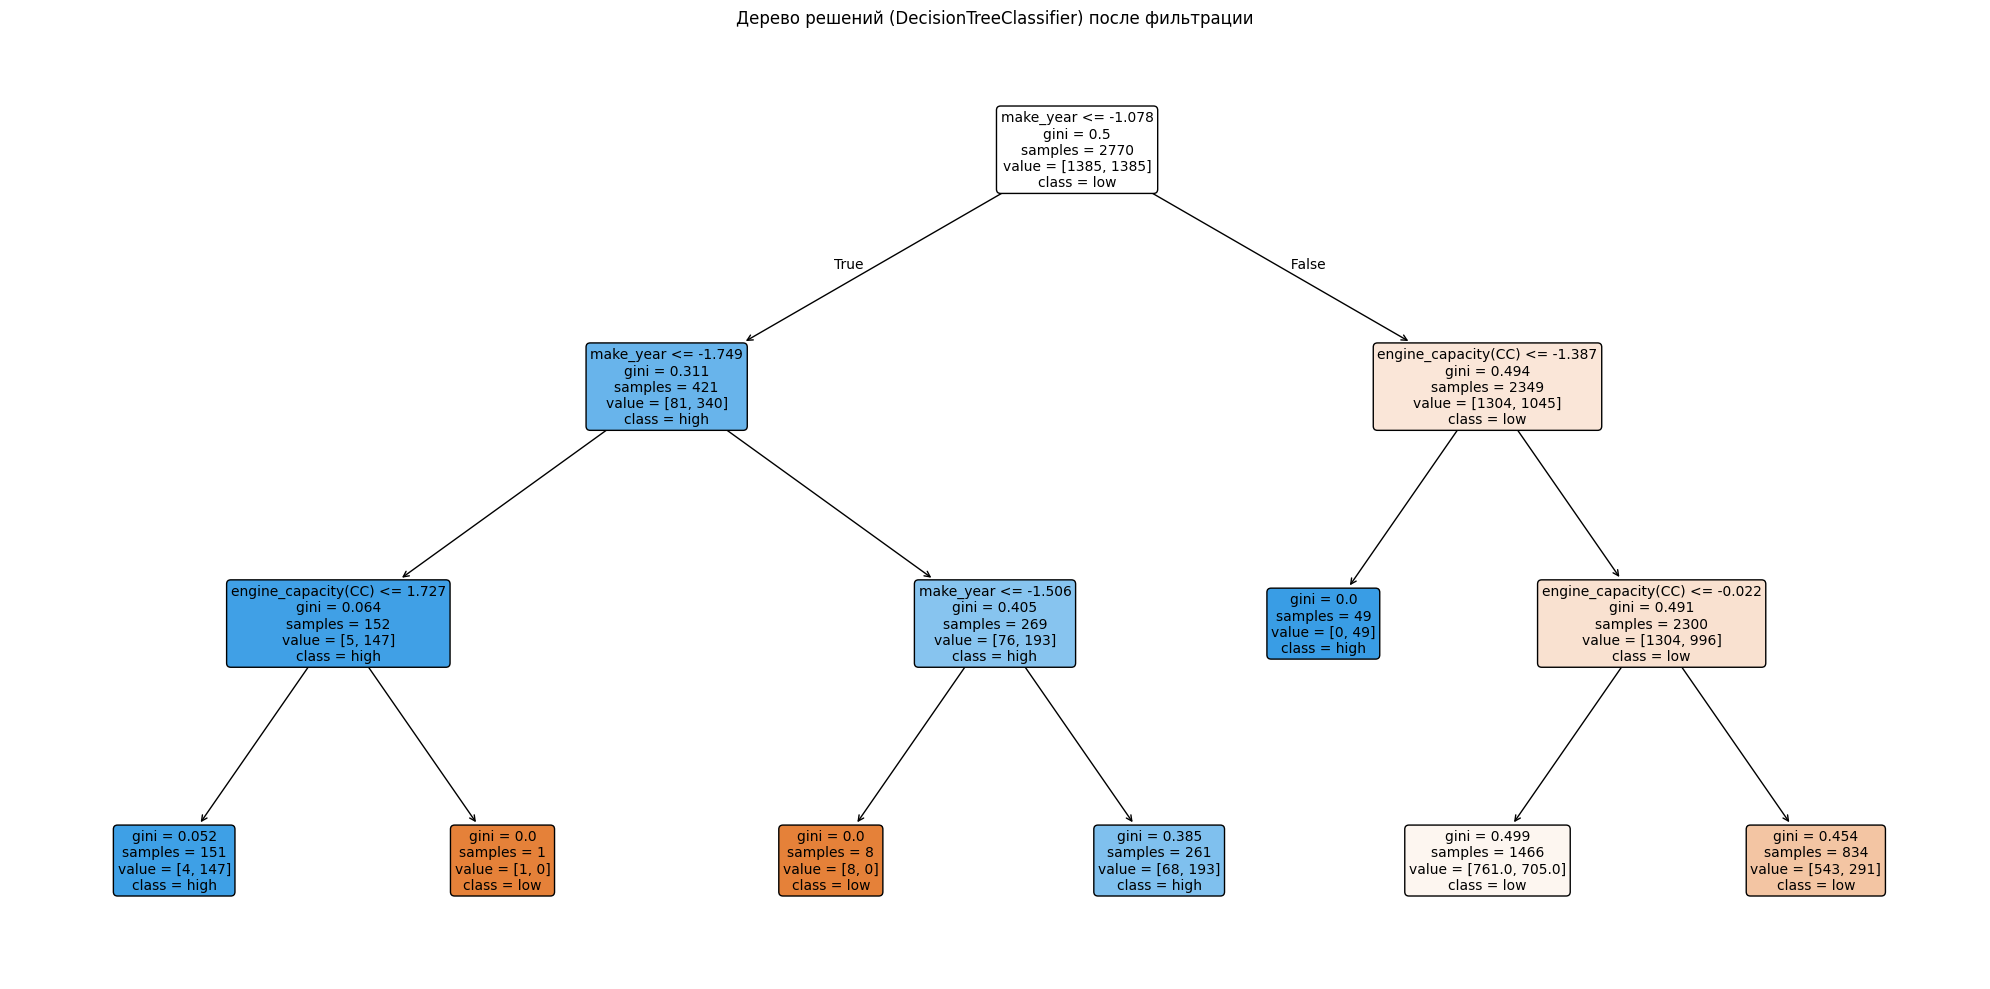

In [60]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

X_train_filt_enc = X_train_resampled.copy()
X_test_filt_enc = X_test.copy()

for col in X_train_filt_enc.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_train_filt_enc[col] = le.fit_transform(X_train_filt_enc[col].astype(str))
    X_test_filt_enc[col] = le.transform(X_test_filt_enc[col].astype(str))

dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train_filt_enc, y_train_resampled)

plt.figure(figsize=(20, 10))
plot_tree(dt_vis, feature_names=X_train_filt_enc.columns, class_names=['low', 'high'],
          filled=True, rounded=True, fontsize=10)
plt.title('Дерево решений (DecisionTreeClassifier) после фильтрации')
plt.tight_layout()
plt.show()

## 5. Регрессия:
   - С использованием `GridSearchCV`/`grid_search` осуществить подбор гиперпараметра модели линейной регрессии с использованием $XGBoost$ или $CatBoost$.
     > [xgboost.XGBRegressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor) в $XGBoost$, [CatBoostRegressor](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor) в $CatBoost$.

In [61]:
from sklearn.model_selection import train_test_split

target = df['price']
X = df.drop(columns='price')
y = target

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, train_size=0.75, random_state=42
)

In [66]:
categorial_cols = ['brand', 'transmission', 'fuel_type', 'ownership', 'spare_key']

In [67]:
cat_features_indices = [X_train_reg.columns.get_loc(c) for c in categorial_cols]

In [69]:
import catboost as cb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

cat_params = {
    'iterations': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'depth': range(3, 8),
    'l2_leaf_reg': [0.1, 1.0]
}

cat_features_indices = [X_train_reg.columns.get_loc(c) for c in categorial_cols]

reg_grid = GridSearchCV(
    cb.CatBoostRegressor(random_state=42),
    param_grid=cat_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=False
)

reg_grid.fit(X_train_reg, y_train_reg, cat_features=cat_features_indices)


best_reg = reg_grid.best_estimator_
y_pred_reg = best_reg.predict(X_test_reg)

print("CatBoost регрессия лучшие параметры:", reg_grid.best_params_)

0:	learn: 0.9068239	total: 1.7ms	remaining: 338ms
1:	learn: 0.8346440	total: 3.61ms	remaining: 358ms
2:	learn: 0.7708544	total: 4.96ms	remaining: 326ms
3:	learn: 0.7117355	total: 6.24ms	remaining: 306ms
4:	learn: 0.6572954	total: 7.56ms	remaining: 295ms
5:	learn: 0.6092285	total: 8.9ms	remaining: 288ms
6:	learn: 0.5626524	total: 10.2ms	remaining: 281ms
7:	learn: 0.5224811	total: 13.1ms	remaining: 315ms
8:	learn: 0.4861552	total: 18ms	remaining: 382ms
9:	learn: 0.4504232	total: 22.1ms	remaining: 420ms
10:	learn: 0.4194501	total: 25.8ms	remaining: 443ms
11:	learn: 0.3907340	total: 30ms	remaining: 470ms
12:	learn: 0.3645148	total: 32.9ms	remaining: 473ms
13:	learn: 0.3395114	total: 34.4ms	remaining: 457ms
14:	learn: 0.3166054	total: 36.4ms	remaining: 449ms
15:	learn: 0.2975013	total: 37.8ms	remaining: 434ms
16:	learn: 0.2798764	total: 39.4ms	remaining: 424ms
17:	learn: 0.2645219	total: 41.4ms	remaining: 419ms
18:	learn: 0.2495013	total: 42.9ms	remaining: 408ms
19:	learn: 0.2350005	total: 

   - Вывести метрики $MSE$, $MAE$ и $R^2$ на тестовом наборе.

In [71]:
print(f"MSE: {mean_squared_error(y_test_reg, y_pred_reg):.4f}")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"R²: {r2_score(y_test_reg, y_pred_reg):.4f}")

MSE: 0.0063
MAE: 0.0378
R²: 0.9940


Результаты регрессии впечатлили! `R_2` практически единицы, а значения `MSE` и `MAE` близки к 0.

   - Осуществить фильтрацию признаков по аналогии с пунктом 4.

In [72]:
import numpy as np
import shap

explainer_reg = shap.TreeExplainer(best_reg)
shap_values_reg = explainer_reg.shap_values(X_test_reg)

mean_abs_shap_reg = np.abs(shap_values_reg).mean(axis=0)
importance_shap_reg = pd.DataFrame({'feature': X_test_reg.columns, 'importance': mean_abs_shap_reg}).sort_values('importance', ascending=False)
print(importance_shap_reg)

               feature  importance
7         overall_cost    0.700895
2            make_year    0.149408
3            fuel_type    0.016495
5            km_driven    0.010462
4  engine_capacity(CC)    0.007298
0                brand    0.001784
1         transmission    0.001700
6            ownership    0.000544
8            spare_key    0.000000


Отфильтруем, используя медианное значение.

In [73]:
important_feature = importance_shap_reg.feature[importance_shap_reg.importance > np.median(importance_shap_reg.importance)]

   - Переобучить модель на отфильтрованном наборе признаков.

In [78]:
categorial_cols_reg = ['fuel_type']

In [79]:
cat_features_indices = [X_train_reg.columns.get_loc(c) for c in categorial_cols_reg]

In [80]:
X_train_reg = X_train_reg[important_feature]
X_test_reg = X_test_reg[important_feature]

reg = cb.CatBoostRegressor(
    depth = 6,
    iterations =200,
    l2_leaf_reg = 1.0,
    learning_rate = 0.1
)

reg.fit(X_train_reg, y_train_reg, cat_features=cat_features_indices)

y_pred_reg = reg.predict(X_test_reg)


0:	learn: 0.9016269	total: 2.36ms	remaining: 469ms
1:	learn: 0.8250722	total: 4.55ms	remaining: 451ms
2:	learn: 0.7558544	total: 6.46ms	remaining: 424ms
3:	learn: 0.6938700	total: 8.39ms	remaining: 411ms
4:	learn: 0.6345773	total: 10.2ms	remaining: 400ms
5:	learn: 0.5794560	total: 12.1ms	remaining: 390ms
6:	learn: 0.5302153	total: 13.9ms	remaining: 383ms
7:	learn: 0.4842355	total: 15.7ms	remaining: 377ms
8:	learn: 0.4448717	total: 17.6ms	remaining: 373ms
9:	learn: 0.4092971	total: 19.4ms	remaining: 369ms
10:	learn: 0.3769113	total: 21.3ms	remaining: 366ms
11:	learn: 0.3468654	total: 23.1ms	remaining: 362ms
12:	learn: 0.3222553	total: 24.9ms	remaining: 358ms
13:	learn: 0.2987093	total: 26.7ms	remaining: 355ms
14:	learn: 0.2766714	total: 28.6ms	remaining: 353ms
15:	learn: 0.2584755	total: 30.6ms	remaining: 352ms
16:	learn: 0.2407872	total: 32.4ms	remaining: 349ms
17:	learn: 0.2239926	total: 34.2ms	remaining: 346ms
18:	learn: 0.2085514	total: 36.3ms	remaining: 346ms
19:	learn: 0.1954393	t

 - Сравнить метрики до и после фильтрации.

In [81]:
print(f"MSE: {mean_squared_error(y_test_reg, y_pred_reg):.4f}")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"R²: {r2_score(y_test_reg, y_pred_reg):.4f}")

MSE: 0.0050
MAE: 0.0302
R²: 0.9953


Значения метрик в целом остались прежними (улучшились не на много), хотя количество признаков сократилось вдвое.